In [ ]:
import pandas as pd

df = pd.read_csv('/content/retail_sales_dataset.csv')

In [ ]:
print("First 4 rows of the dataset:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 4 rows of the dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
#check missing values
print(df.isnull().sum())

#remove duplicates
df.drop_duplicates(inplace=True)

#fill missing values (if any)
df.fillna(method='ffill', inplace=True)

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


/tmp/ipykernel_4054/4135529522.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


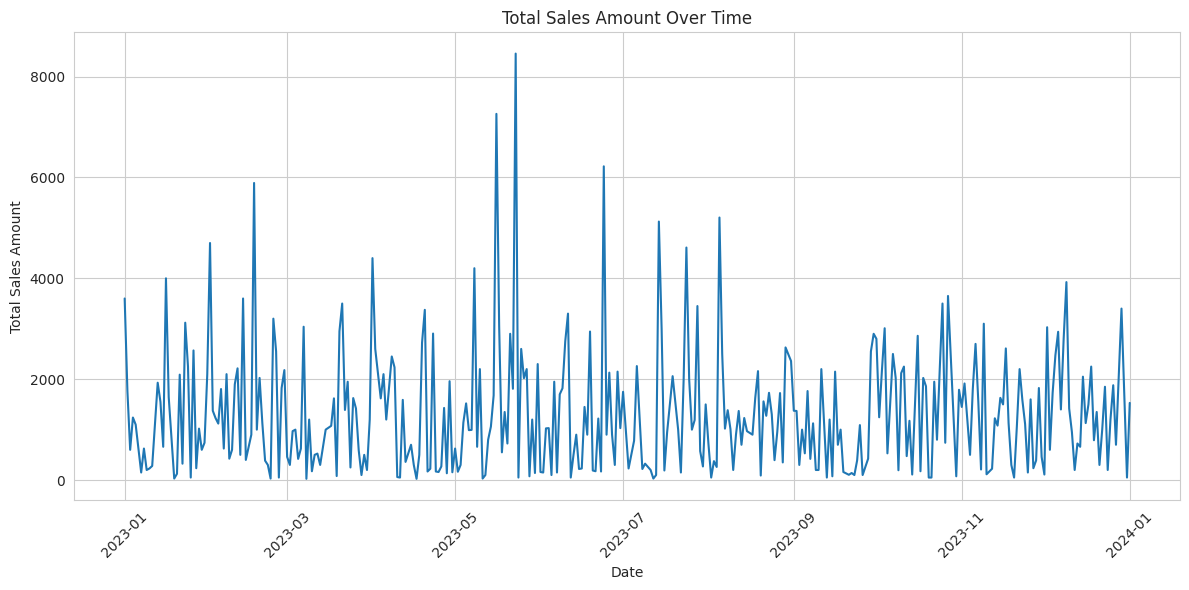

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Group by date and sum the total amount to get daily sales
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Total Amount', data=daily_sales)
plt.title('Total Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4054/2977505411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', data=category_sales, palette='viridis')


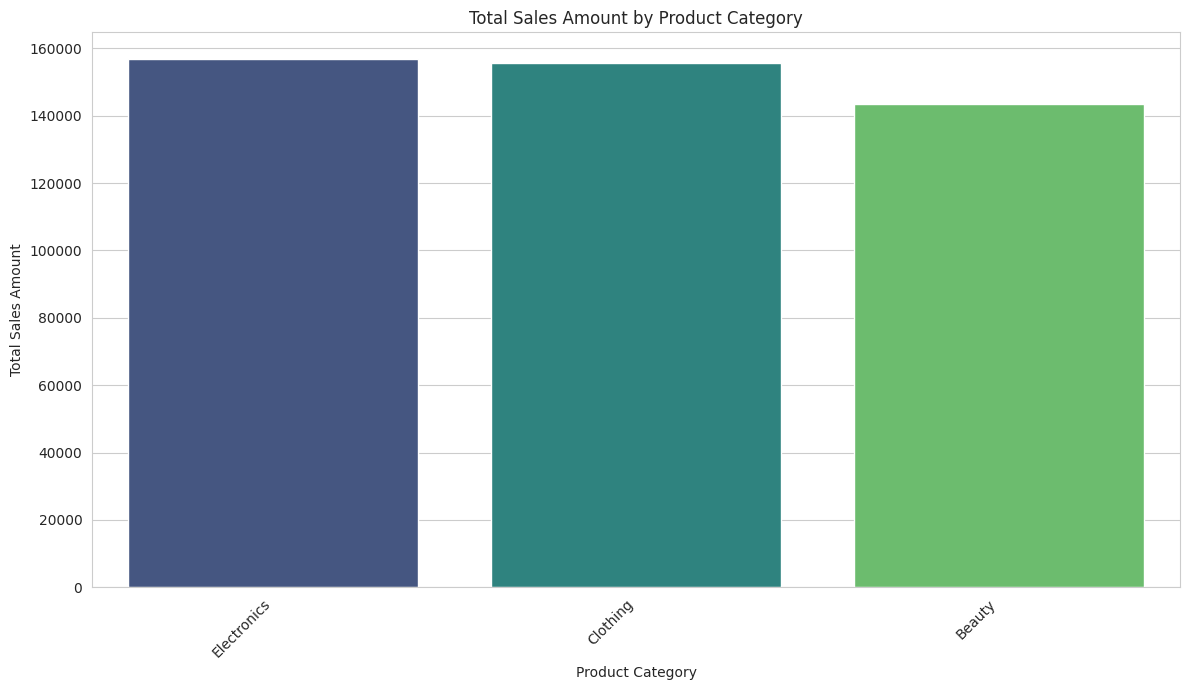

In [ ]:
# Group by Product Category and sum the total amount
category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()

# Sort the categories by total sales in descending order for better visualization
category_sales = category_sales.sort_values(by='Total Amount', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Category', y='Total Amount', data=category_sales, palette='viridis')
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.tight_layout()
plt.show()